# SALES PREDICTION USING PYTHON

# Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ---------------------------------------
# Load Dataset
# ---------------------------------------


In [3]:

df = pd.read_csv("Advertising.csv")

# Show First 5 Rows
print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


# ---------------------------------------
# Dataset Information
# ---------------------------------------

In [4]:
print("\nDataset Info:\n")
print(df.info())



Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None



# ---------------------------------------
# Check Missing Values
# ---------------------------------------


In [5]:

print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


# ---------------------------------------
# Remove Unnecessary Column
# ---------------------------------------


In [6]:
# Remove first unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)


# ---------------------------------------
# Data Visualization
# ---------------------------------------



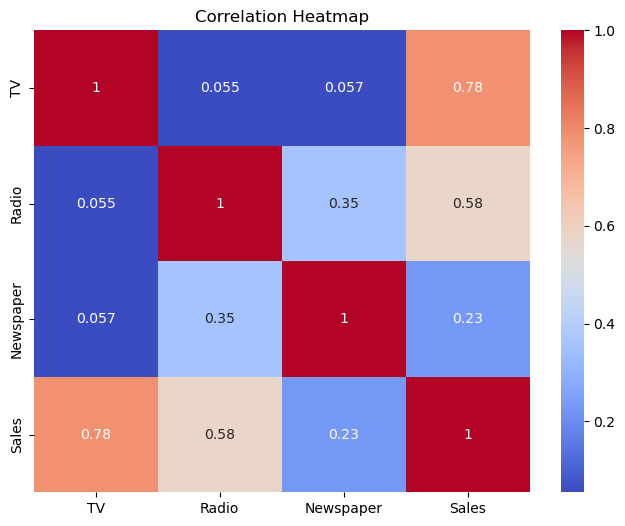

In [7]:
# Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


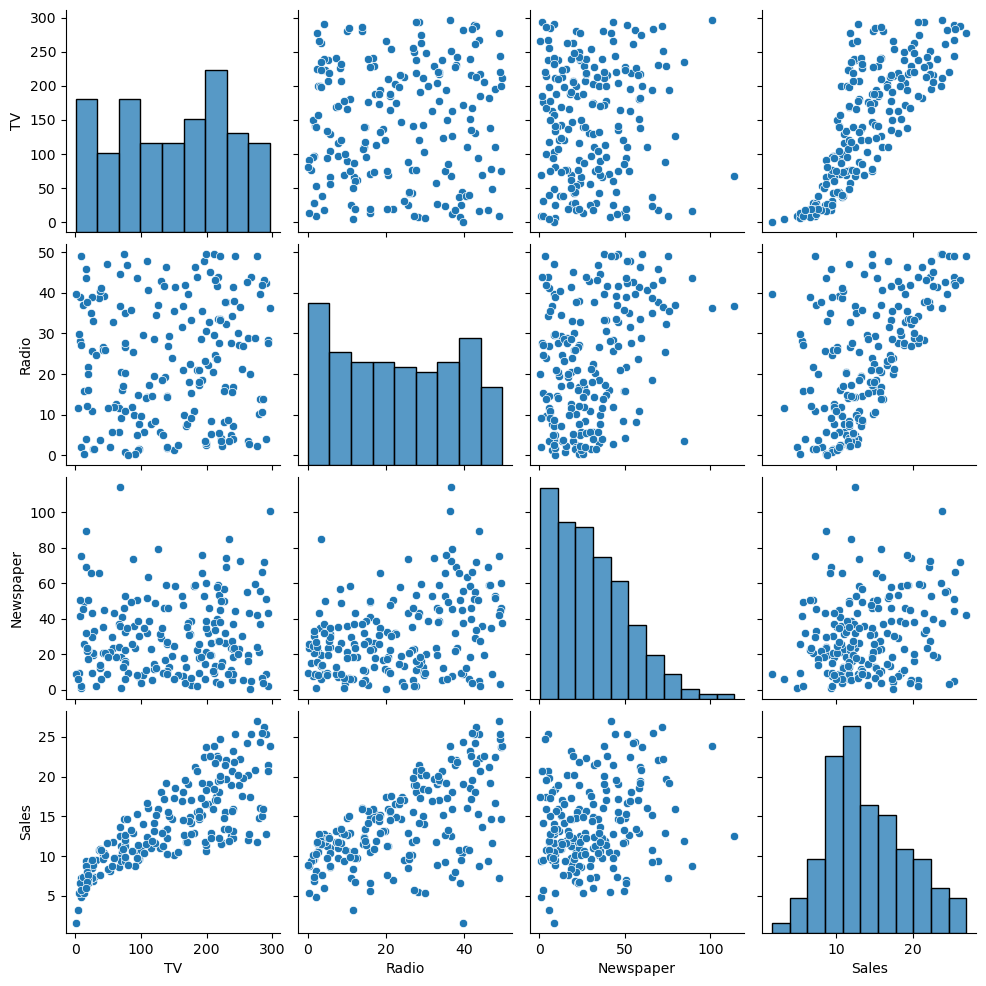

In [8]:

# Pairplot
sns.pairplot(df)
plt.show()

# ---------------------------------------
# Split Dataset
# ---------------------------------------

In [9]:


X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# ---------------------------------------
# Train Machine Learning Model
# ---------------------------------------


In [10]:

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()


# ---------------------------------------
# Predictions
# ---------------------------------------

In [11]:


y_pred = model.predict(X_test)

# ---------------------------------------
# Model Evaluation
# ---------------------------------------


In [12]:

print("\nMean Absolute Error:")
print(mean_absolute_error(y_test, y_pred))

print("\nMean Squared Error:")
print(mean_squared_error(y_test, y_pred))

print("\nR2 Score:")
print(r2_score(y_test, y_pred))



Mean Absolute Error:
1.4607567168117606

Mean Squared Error:
3.1740973539761046

R2 Score:
0.899438024100912


# ---------------------------------------
# Actual vs Predicted Graph
# ---------------------------------------


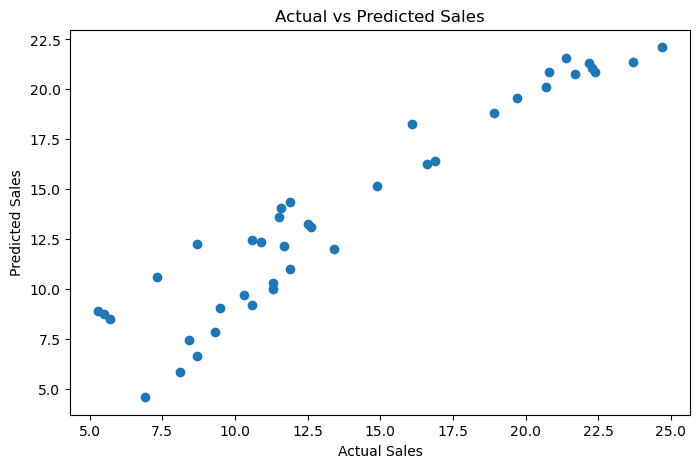

In [13]:

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

# ---------------------------------------
# Predict New Sales
# ---------------------------------------

### Example:
### TV = 230
### Radio = 37
### Newspaper = 69


In [15]:

new_data = pd.DataFrame({
    'TV': [230],
    'Radio': [37],
    'Newspaper': [69]
})

prediction = model.predict(new_data)

print("\nPredicted Sales:")
print(prediction[0])

print("\nSales Prediction Completed Successfully!")


Predicted Sales:
20.45759025215365

Sales Prediction Completed Successfully!
